In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def xi(alpha, r):
    return np.sqrt(alpha**3 / np.pi)* np.exp(-alpha*np.abs(r))


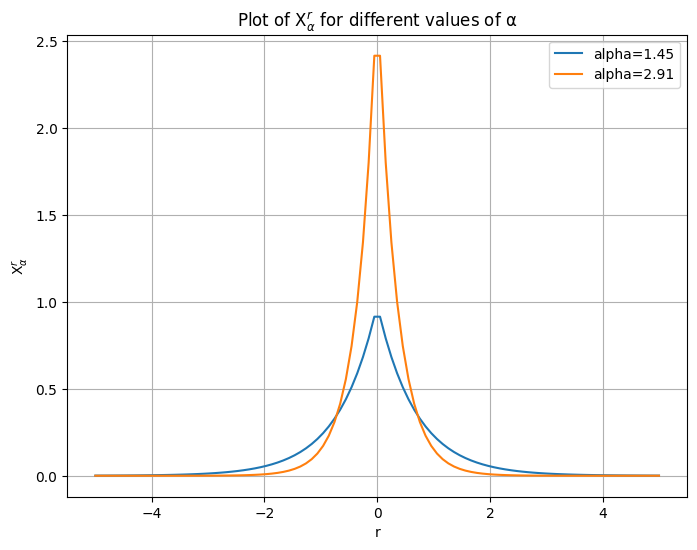

In [3]:
r_values = np.linspace(-5, 5, 100)

# Define the values of alpha
alpha1 = 1.45
alpha2 = 2.91

# Calculate the function values for each alpha and r
xi_values_alpha1 = xi(alpha1, r_values)
xi_values_alpha2 = xi(alpha2, r_values)

# Create a single plot with both curves
plt.figure(figsize=(8, 6))
plt.plot(r_values, xi_values_alpha1, label=f'alpha={alpha1}')
plt.plot(r_values, xi_values_alpha2, label=f'alpha={alpha2}')
plt.xlabel('r')
plt.ylabel('$\u03A7_{\u03B1}^r$')
plt.title('Plot of $\u03A7_{\u03B1}^r$ for different values of \u03B1')
plt.legend()
plt.grid(True)
plt.show()

In [4]:
def S(alpha_p, alpha_q):
    return (2*np.sqrt(alpha_p * alpha_q)/(alpha_p + alpha_q))**3

def I(alpha_p, alpha_q):
    return 4*(np.sqrt(alpha_p * alpha_q)/(alpha_p + alpha_q))**3*(alpha_p*alpha_q - 2*(alpha_p + alpha_q))

def braket_pqrs(alpha_p, alpha_q, alpha_r, alpha_s):
    return 32*(alpha_q*alpha_p*alpha_r*alpha_s)**1.5*(1/((alpha_q+alpha_p)**3*(alpha_r+alpha_s)**2)
                                               -1/((alpha_q+alpha_p)**3*(alpha_p+alpha_q+alpha_r+alpha_s)**2)
                                               -1/((alpha_q+alpha_p)**2*(alpha_p+alpha_q+alpha_r+alpha_s)**3))

alpha_p = 1.45
alpha_q = 2.91

alpha = [0 for x in range(10)]
#alpha[0] = 1
alpha[0] = 1.45
alpha[1] = 2.91


S_pq = np.zeros((2, 2))
for i in range(2):
    for j in range(2):
        S_pq[i,j] = S(alpha[i],alpha[j])
        #print(S(alpha[i],alpha[j]))
print("S_pq = \n", S_pq)

I_pq = np.zeros((2, 2))
for i in range(2):
    for j in range(2):
        I_pq[i,j] = I(alpha[i],alpha[j])

print("I_pq = \n", I_pq)

J_pqrs = np.zeros((2, 2, 2, 2))
for p in range(2):
    for q in range(2):
        for r in range(2):
            for s in range(2):     
                #J_pqrs[i,j] = braket_pqrs(alpha[p],alpha[q],alpha[r],alpha[s])
                J = braket_pqrs(alpha[p],alpha[q],alpha[r],alpha[s])
                J_pqrs[p,q,r,s] = J
                print(f"<{p}{q}|{r}{s}> = ", J)
#print(J_pqrs)


S_pq = 
 [[1.         0.83660799]
 [0.83660799 1.        ]]
I_pq = 
 [[-1.84875    -1.88257712]
 [-1.88257712 -1.58595   ]]
<00|00> =  0.90625
<00|01> =  0.9032809689802691
<00|10> =  0.9032809689802692
<00|11> =  1.1825891959996644
<01|00> =  0.9032809689802689
<01|01> =  0.9536313570462885
<01|10> =  0.9536313570462885
<01|11> =  1.2979962750972307
<10|00> =  0.9032809689802689
<10|01> =  0.9536313570462885
<10|10> =  0.9536313570462885
<10|11> =  1.2979962750972307
<11|00> =  1.182589195999665
<11|01> =  1.297996275097231
<11|10> =  1.297996275097231
<11|11> =  1.8187499999999999


In [5]:
C = [1, 0]
def Fpq(C):
    F_pq = np.zeros((2,2))
    for p in range(2):
        for q in range(2):
            F_pq[p,q] = I_pq[p,q]
            for r in range(2):
                for s in range(2): 
                    F_pq[p,q] += C[r]*C[s]*J_pqrs[p,q,r,s]
    return F_pq

F_pq = Fpq(C)
print("F_pq =\n", F_pq)

# Energy
E = 0
for p in range(2):
    for q in range(2):
        E += C[p]*C[q]*(I_pq[p,q] + F_pq[p,q]) 
print("E0 =", E*27.2114, "ev")


F_pq =
 [[-0.9425     -0.97929615]
 [-0.97929615 -0.4033608 ]]
E0 = -75.95382024999999 ev


In [6]:
energy = []
k=0
F=F_pq
while k<12:
    k+=1

    
    # part c
    eig_val, P = np.linalg.eig(S_pq)
    # Diagonal matrix 
    #SD = np.diag(eig_val)
    SD_sqrt_inv = np.diag(1/np.sqrt(eig_val))

    # Inverse of eigenvectors matrix P
    S_sqrt_inv = np.dot(np.dot(P, SD_sqrt_inv), np.linalg.inv(P))

    #print("S^-1/2 =\n",S_sqrt_inv)
    F_prime = np.dot(np.dot(S_sqrt_inv,F),S_sqrt_inv)
    #print("F' =\n",F_prime)
    eig_val, eig_vect = np.linalg.eig(F_prime)
    # Diagonal matrix 
    eps = np.diag(eig_val)
    #print('espilon = \n',eps)
    # Inverse of eigenvectors matrix P
    C_prime = eig_vect
    #print("C' = \n",C_prime)
    C = S_sqrt_inv@C_prime
    #print("C = \n",C)

    F = Fpq(C[:,0])
    # Energy
    E = 0
    for p in range(2):
        for q in range(2):
            E += C[p]*C[q]*(I_pq[p,q] + F[p,q]) 
    energy.append(E*27.2114)
    #print("E0 =", E*27.2114, "ev")
print(energy)

[array([-77.79890675,  83.52291562]), array([-77.86730587,  82.61218121]), array([-77.86993041,  82.80619707]), array([-77.87003072,  82.7688641 ]), array([-77.87003455,  82.77618856]), array([-77.8700347 ,  82.77475702]), array([-77.87003471,  82.77503702]), array([-77.87003471,  82.77498226]), array([-77.87003471,  82.77499297]), array([-77.87003471,  82.77499087]), array([-77.87003471,  82.77499128]), array([-77.87003471,  82.7749912 ])]


In [7]:
# part c
eig_val, eig_vect = np.linalg.eig(S_pq)

# Diagonal matrix 
SD = np.diag(eig_val)

SD_sqrt_inv = np.diag(1/np.sqrt(eig_val))

# Inverse of eigenvectors matrix P
P = eig_vect

S_sqrt_inv = np.dot(np.dot(P, SD_sqrt_inv), np.linalg.inv(P))

print("S^-1/2 =\n",S_sqrt_inv)


S^-1/2 =
 [[ 1.60590209 -0.86801185]
 [-0.86801185  1.60590209]]


In [8]:
F_prime = np.dot(np.dot(S_sqrt_inv,F_pq),S_sqrt_inv)
print("F' =\n",F_prime)


F' =
 [[-0.00437938 -1.38732133]
 [-1.38732133  0.97980679]]


In [9]:
eig_val, eig_vect = np.linalg.eig(F_prime)

# Diagonal matrix 
eps = np.diag(eig_val)
print('espilon = \n',eps)
# Inverse of eigenvectors matrix P
C_prime = eig_vect
print("C' = \n",C_prime)
C = S_sqrt_inv@C_prime
print("C = \n",C)


espilon = 
 [[-0.98429719  0.        ]
 [ 0.          1.9597246 ]]
C' = 
 [[-0.81679247  0.57693158]
 [-0.57693158 -0.81679247]]
C = 
 [[-0.81090529  1.63548118]
 [-0.21751009 -1.81247219]]


In [10]:
# Energy
E = 0
for p in range(2):
    for q in range(2):
        E += C[p]*C[q]*(I_pq[p,q] + F_pq[p,q]) 
print("E0 =", E*27.2114, "ev")

E0 = [-79.97717349  80.69999484] ev
